# Proyecto ABP: Factores asociados a la supervivencia de pasajeros del Titanic

## Fase 1 - Avance sumativo del análisis exploratorio de datos y reproducibilidad

**MCDI503 - Exploración Inteligente para la Ciencia de Datos**  
**Integrantes:** Jennifer Nilo, Patricio Núñez  
**Grupo:** 08  
**Fecha:** 08 de septiembre de 2026  
**Repositorio:** https://github.com/pnunezcarreno/exploracion_inteligente  


### Estructura del notebook

El análisis mantiene la caracterización inicial y continúa con la implementación práctica del EDA. Después de las secciones de contexto, carga, calidad y exploración preliminar se presentan las transformaciones y los resultados. Finalmente, se consolidan las decisiones, la trazabilidad, la organización aplicada, la reproducibilidad, las limitaciones y las conclusiones del avance completo.

| Elemento solicitado | Evidencia en el notebook |
|---|---|
| I. Identificación del proyecto | Portada y secciones 1–2 |
| II. Contexto y objetivo exploratorio | Secciones 1 y 8 |
| III. Carga y revisión inicial | Secciones 3–7 |
| IV. Exploración preliminar | Secciones 9–10 |
| V. Decisiones y transformaciones iniciales | Secciones 11 y 13 |
| VI. Resultados e interpretación inicial | Secciones 12 y 14 |
| VII. Supuestos y limitaciones | Secciones 15–18 |
| VIII. Cierre del avance | Sección 19 |


## 1. Contexto y propósito

El hundimiento del Titanic dejó un registro de pasajeros con características demográficas, familiares y vinculadas al viaje. Este proyecto propone explorar cómo varía la supervivencia entre los grupos representados en el dataset, considerando variables como el sexo registrado, la edad, la clase del pasaje, la tarifa, el puerto de embarque y si la persona viajaba sola.

El propósito general es construir una descripción clara de los datos y reconocer patrones que orienten las siguientes etapas del curso. El análisis puede ayudar a comprender qué grupos presentan diferencias en la supervivencia dentro de esta muestra, además de mostrar cómo la calidad de los datos condiciona las conclusiones. El valor del caso es principalmente educativo y metodológico: permite trabajar con variables numéricas y categóricas, valores faltantes, redundancias y comparaciones entre grupos (Universidad Andrés Bello [UNAB], 2026a).

> El análisis será descriptivo y exploratorio. Una asociación observada no se interpretará como una relación causal.


## 2. Descripción del conjunto de datos

Se utilizará la versión pública de `titanic.csv` mantenida en el repositorio **seaborn-data** (Waskom, s. f.).

- **Unidad de análisis:** un registro con atributos de un pasajero.
- **Tamaño esperado:** 891 registros y 15 variables.
- **Variable de interés:** `survived`, que indica supervivencia con valores 0 y 1.
- **Variables explicativas iniciales:** `sex`, `age`, `pclass`, `fare`, `embark_town`, `alone`, `sibsp` y `parch`.
- **Aspectos de calidad previstos:** valores faltantes en edad, cubierta y puerto de embarque; variables redundantes; ausencia de un identificador único en esta versión.


## 3. Configuración del entorno reproducible

Se importan únicamente librerías disponibles por defecto en Google Colab. También se fija una semilla, aunque en esta etapa no se ejecutan procesos aleatorios. La versión de cada librería queda registrada para facilitar la comparación entre ejecuciones y reducir dependencias ocultas (Rule et al., 2019).


In [1]:
import platform

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

SEMILLA = 42
np.random.seed(SEMILLA)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

versiones = pd.Series(
    {
        "Python": platform.python_version(),
        "pandas": pd.__version__,
        "NumPy": np.__version__,
        "Seaborn": sns.__version__,
        "Matplotlib": matplotlib.__version__,
        "Semilla": SEMILLA,
    },
    name="Versión / valor",
)
versiones.to_frame()


,Versión / valor
Python,3.13.15
pandas,2.2.3
NumPy,2.1.3
Seaborn,0.13.2
Matplotlib,3.10.0
Semilla,42


## 4. Carga de los datos

El conjunto de datos se carga directamente desde la biblioteca Seaborn mediante `sns.load_dataset("titanic")` (Waskom, 2024). Después de la carga se comprueban sus dimensiones y columnas para confirmar que la estructura sea la esperada.

La tabla obtenida se conserva en `titanic_raw`. La exploración se realiza sobre una copia llamada `titanic`, evitando modificar directamente los datos cargados.


In [2]:
titanic_raw = sns.load_dataset("titanic")

COLUMNAS_ESPERADAS = [
    "survived", "pclass", "sex", "age", "sibsp", "parch", "fare",
    "embarked", "class", "who", "adult_male", "deck", "embark_town",
    "alive", "alone",
]

assert titanic_raw.shape == (891, 15), "Las dimensiones no coinciden con la versión documentada."
assert titanic_raw.columns.tolist() == COLUMNAS_ESPERADAS, "Cambió el esquema del dataset."

titanic = titanic_raw.copy(deep=True)

print("Carga completada desde Seaborn")
print(f"Dimensiones: {titanic.shape[0]} filas x {titanic.shape[1]} columnas")


Carga completada desde Seaborn
Dimensiones: 891 filas x 15 columnas


**Tabla 1. Vista inicial del conjunto de datos Titanic.**  
*Nota.* Se presentan los primeros cinco registros de la copia de trabajo `titanic`.


In [3]:
# Vista breve para comprobar contenido y formato.
titanic.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 5. Diccionario inicial de variables

El siguiente diccionario documenta el significado operativo que se utilizará durante el proyecto. La distinción entre variables originales y variables derivadas será relevante más adelante, especialmente porque algunas columnas representan la misma información con otra codificación (UNAB, 2026a).

**Tabla 2. Diccionario inicial de variables.**


In [4]:
diccionario_variables = pd.DataFrame([
    ("survived", "Numérica binaria", "Supervivencia: 0 = no, 1 = sí", "Variable de interés"),
    ("pclass", "Ordinal", "Clase del pasaje: 1, 2 o 3", "Explicativa"),
    ("sex", "Categórica", "Sexo registrado en el dataset", "Explicativa"),
    ("age", "Numérica continua", "Edad en años; contiene valores faltantes", "Explicativa"),
    ("sibsp", "Numérica discreta", "Número de hermanos/as o cónyuges a bordo", "Explicativa"),
    ("parch", "Numérica discreta", "Número de padres/madres o hijos/as a bordo", "Explicativa"),
    ("fare", "Numérica continua", "Tarifa pagada por el pasaje", "Explicativa"),
    ("embarked", "Categórica", "Código del puerto de embarque: C, Q o S", "Explicativa"),
    ("class", "Ordinal", "Clase del pasaje expresada como First, Second o Third", "Redundante con pclass"),
    ("who", "Categórica", "Agrupación derivada: man, woman o child", "Derivada"),
    ("adult_male", "Booleana", "Indica si el registro corresponde a un hombre adulto", "Derivada"),
    ("deck", "Categórica", "Cubierta registrada; presenta alta ausencia", "Explicativa / a evaluar"),
    ("embark_town", "Categórica", "Nombre del puerto de embarque", "Redundante con embarked"),
    ("alive", "Categórica", "Supervivencia expresada como yes o no", "Redundante con survived"),
    ("alone", "Booleana", "Indica si viajaba sin familiares registrados", "Derivada"),
], columns=["Variable", "Tipo conceptual", "Descripción", "Rol inicial"])

diccionario_variables


,Variable,Tipo conceptual,Descripción,Rol inicial
0,survived,Numérica binaria,"Supervivencia: 0 = no, 1 = sí",Variable de interés
1,pclass,Ordinal,"Clase del pasaje: 1, 2 o 3",Explicativa
2,sex,Categórica,Sexo registrado en el dataset,Explicativa
3,age,Numérica continua,Edad en años; contiene valores faltantes,Explicativa
4,sibsp,Numérica discreta,Número de hermanos/as o cónyuges a bordo,Explicativa
5,parch,Numérica discreta,Número de padres/madres o hijos/as a bordo,Explicativa
6,fare,Numérica continua,Tarifa pagada por el pasaje,Explicativa
7,embarked,Categórica,"Código del puerto de embarque: C, Q o S",Explicativa
8,class,Ordinal,"Clase del pasaje expresada como First, Second ...",Redundante con pclass
9,who,Categórica,"Agrupación derivada: man, woman o child",Derivada


## 6. Inspección estructural

Antes de construir gráficos se revisan dimensiones, tipos de datos y cardinalidad. Esta inspección permite reconocer problemas de representación y decidir qué análisis son apropiados para cada variable (McKinney, 2010).

**Tabla 3. Estructura, completitud y cardinalidad por variable.**


In [5]:
estructura = pd.DataFrame({
    "tipo_pandas": titanic.dtypes.astype(str),
    "no_nulos": titanic.notna().sum(),
    "nulos": titanic.isna().sum(),
    "valores_unicos": titanic.nunique(dropna=True),
})
estructura.index.name = "variable"
estructura


,tipo_pandas,no_nulos,nulos,valores_unicos
variable,,,,
survived,int64,891,0,2
pclass,int64,891,0,3
sex,object,891,0,2
age,float64,714,177,88
sibsp,int64,891,0,7
parch,int64,891,0,7
fare,float64,891,0,248
embarked,object,889,2,3
class,category,891,0,3


In [6]:
# Resumen equivalente a info(), útil para revisar uso de memoria y tipos.
titanic.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


## 7. Diagnóstico inicial de calidad

Esta etapa cuantifica valores faltantes, revisa filas exactamente iguales y verifica coherencia entre variables que codifican información equivalente. Todavía no se imputan valores, no se eliminan registros y no se recodifican categorías, de acuerdo con el carácter inicial de este diagnóstico (UNAB, 2026a).

**Tabla 4. Perfil inicial de calidad por variable.**


In [7]:
def resumen_calidad(df: pd.DataFrame) -> pd.DataFrame:
    # Construye un perfil compacto y reproducible por variable.
    ejemplos = []
    for columna in df.columns:
        valores = df[columna].dropna().astype(str).unique()[:3]
        ejemplos.append(", ".join(valores))

    resultado = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "nulos": df.isna().sum(),
        "nulos_pct": (df.isna().mean() * 100).round(2),
        "unicos": df.nunique(dropna=True),
        "ejemplos": ejemplos,
    })
    resultado.index.name = "variable"
    return resultado.sort_values(["nulos_pct", "variable"], ascending=[False, True])


calidad = resumen_calidad(titanic)
calidad


,tipo,nulos,nulos_pct,unicos,ejemplos
variable,,,,,
deck,category,688,77.22,7,"C, E, G"
age,float64,177,19.87,88,"22.0, 38.0, 26.0"
embark_town,object,2,0.22,3,"Southampton, Cherbourg, Queenstown"
embarked,object,2,0.22,3,"S, C, Q"
adult_male,bool,0,0.00,2,"True, False"
alive,object,0,0.00,2,"no, yes"
alone,bool,0,0.00,2,"False, True"
class,category,0,0.00,3,"Third, First, Second"
fare,float64,0,0.00,248,"7.25, 71.2833, 7.925"


In [8]:
n_filas_repetidas = int(titanic.duplicated().sum())

display(Markdown(
    f"""
**Lectura inicial de completitud**

- `deck` concentra **{titanic['deck'].isna().sum()}** valores faltantes ({titanic['deck'].isna().mean():.1%}).
- `age` presenta **{titanic['age'].isna().sum()}** valores faltantes ({titanic['age'].isna().mean():.1%}).
- `embarked` y `embark_town` presentan **{titanic['embarked'].isna().sum()}** valores faltantes cada una.
- Se observan **{n_filas_repetidas}** filas exactamente iguales considerando las 15 columnas.

Estas filas no se eliminarán de forma automática. El dataset no incluye un identificador de pasajero, nombre ni número de ticket, por lo que dos registros iguales podrían corresponder a personas distintas con los mismos atributos disponibles.
"""
))



**Lectura inicial de completitud**

- `deck` concentra **688** valores faltantes (77.2%).
- `age` presenta **177** valores faltantes (19.9%).
- `embarked` y `embark_town` presentan **2** valores faltantes cada una.
- Se observan **107** filas exactamente iguales considerando las 15 columnas.

Estas filas no se eliminarán de forma automática. El dataset no incluye un identificador de pasajero, nombre ni número de ticket, por lo que dos registros iguales podrían corresponder a personas distintas con los mismos atributos disponibles.


**Tabla 5. Controles de coherencia entre variables equivalentes.**


In [9]:
# Comprobaciones de coherencia entre representaciones redundantes.
mapa_clase = {1: "First", 2: "Second", 3: "Third"}
mapa_supervivencia = {0: "no", 1: "yes"}
mapa_puerto = {"C": "Cherbourg", "Q": "Queenstown", "S": "Southampton"}

controles_coherencia = pd.Series({
    "survived coincide con alive": titanic["survived"].map(mapa_supervivencia).eq(titanic["alive"]).all(),
    "pclass coincide con class": titanic["pclass"].map(mapa_clase).eq(titanic["class"]).all(),
    "embarked coincide con embark_town": titanic["embarked"].map(mapa_puerto).equals(titanic["embark_town"]),
    "alone coincide con sibsp + parch = 0": titanic["alone"].eq((titanic["sibsp"] + titanic["parch"]) == 0).all(),
}, name="resultado")

controles_coherencia.to_frame()


,resultado
survived coincide con alive,True
pclass coincide con class,True
embarked coincide con embark_town,True
alone coincide con sibsp + parch = 0,True


### Decisión preliminar sobre variables redundantes

Las validaciones muestran que `alive`, `class` y `embark_town` reproducen información presente en `survived`, `pclass` y `embarked`. Para evitar doble conteo o interpretaciones circulares, el análisis principal usará:

- `survived` como variable de interés;
- `pclass` para representar la clase;
- `embark_town` para presentar el puerto con nombres legibles.

Las columnas redundantes se conservarán en esta etapa para mantener intacta la fuente. Su eventual exclusión se aplicará solo sobre una tabla de trabajo y quedará registrada.


## 8. Preguntas exploratorias iniciales, supuestos y objetivo

**Objetivo exploratorio:** caracterizar la estructura y calidad del conjunto de datos y describir cómo varía la supervivencia según sexo registrado, clase, edad, tarifa, contexto familiar y puerto de embarque. Las preguntas permiten ordenar el análisis y relacionar cada acción con una evidencia concreta (UNAB, 2026a, 2026c).

| Pregunta exploratoria | Supuesto preliminar | Variables principales |
|---|---|---|
| ¿Cómo varía la proporción de supervivencia según el sexo registrado y la clase del pasaje? | Podrían observarse diferencias entre grupos, pero la composición por edad y clase puede influir en la comparación. | `survived`, `sex`, `pclass` |
| ¿La distribución de edad cambia entre quienes sobrevivieron y quienes no? | Las edades podrían presentar distribuciones diferentes. Los datos faltantes deben cuantificarse antes de comparar. | `survived`, `age` |
| ¿Qué relación descriptiva existe entre la tarifa, la clase y la supervivencia? | La tarifa puede reflejar parcialmente la clase y no debe interpretarse como una causa independiente. | `fare`, `pclass`, `survived` |
| ¿Viajar solo o con familiares se asocia con diferencias en la supervivencia? | `alone`, `sibsp` y `parch` permiten aproximar la composición familiar, aunque no describen todos los vínculos entre pasajeros. | `alone`, `sibsp`, `parch`, `survived` |
| ¿El puerto de embarque presenta diferencias en la supervivencia y en la composición por clase? | Una diferencia por puerto podría estar vinculada con la distribución de clases y no con el puerto por sí mismo. | `embark_town`, `pclass`, `survived` |

### Alcance de esta entrega

En este avance se responderán preguntas de caracterización y comparación descriptiva: estructura, completitud, coherencia, distribución general y diferencias iniciales entre grupos. El tratamiento definitivo de faltantes, las pruebas de hipótesis, el modelamiento predictivo y cualquier interpretación causal quedan fuera del alcance de esta entrega.


## 9. Descripción estadística inicial

Se construye una síntesis numérica y categórica básica. Su función es comprobar rangos y categorías antes de diseñar comparaciones más profundas mediante operaciones reproducibles sobre datos tabulares (The pandas development team, 2026).

**Tabla 6. Resumen descriptivo inicial de variables numéricas.**


In [10]:
variables_numericas = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
titanic[variables_numericas].describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
variable,,,,,,,,
survived,891.0,0.38,0.49,0.00,0.00,0.00,1.0,1.00
pclass,891.0,2.31,0.84,1.00,2.00,3.00,3.0,3.00
age,714.0,29.70,14.53,0.42,20.12,28.00,38.0,80.00
sibsp,891.0,0.52,1.10,0.00,0.00,0.00,1.0,8.00
parch,891.0,0.38,0.81,0.00,0.00,0.00,0.0,6.00
fare,891.0,32.20,49.69,0.00,7.91,14.45,31.0,512.33


**Tabla 7. Frecuencias y porcentajes de variables categóricas.**  
*Nota.* Los porcentajes se calculan dentro de cada variable e incluyen valores ausentes.


In [11]:
variables_categoricas = ["sex", "class", "embark_town", "who", "alone"]

frecuencias = pd.concat(
    {
        columna: titanic[columna].value_counts(dropna=False)
        for columna in variables_categoricas
    },
    names=["variable", "categoria"],
).rename("frecuencia").to_frame()
frecuencias["porcentaje"] = (
    frecuencias["frecuencia"]
    / frecuencias.groupby(level="variable")["frecuencia"].transform("sum")
    * 100
).round(2)

frecuencias


frecuencia  porcentaje
variable    categoria                          
sex         male                577       64.76
            female              314       35.24
class       Third               491       55.11
            First               216       24.24
            Second              184       20.65
embark_town Southampton         644       72.28
            Cherbourg           168       18.86
            Queenstown           77        8.64
            NaN                   2        0.22
who         man                 537       60.27
            woman               271       30.42
            child                83        9.32
alone       True                537       60.27
            False               354       39.73

## 10. Visualizaciones diagnósticas iniciales

Estas visualizaciones se incluyen para orientar la planificación y reconocer patrones iniciales (Waskom, 2021). No constituyen todavía un EDA completo ni una prueba de hipótesis.


**Figura 1. Porcentaje de valores faltantes por variable.**


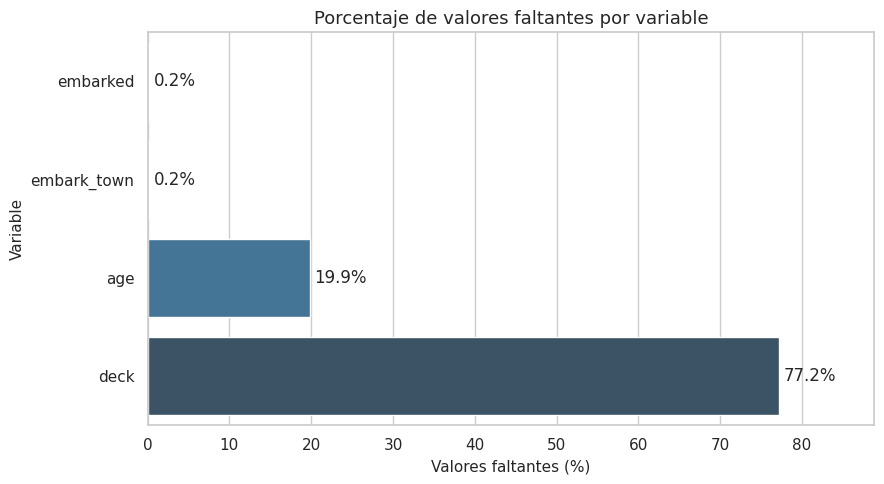

In [12]:
faltantes = calidad.loc[calidad["nulos"] > 0].sort_values("nulos_pct")

ax = sns.barplot(
    data=faltantes.reset_index(),
    x="nulos_pct",
    y="variable",
    hue="variable",
    legend=False,
    palette="Blues_d",
)
ax.set_title("Porcentaje de valores faltantes por variable")
ax.set_xlabel("Valores faltantes (%)")
ax.set_ylabel("Variable")

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="%.1f%%", padding=3)

plt.xlim(0, max(faltantes["nulos_pct"]) * 1.15)
plt.tight_layout()
plt.show()


**Figura 2. Distribuciones iniciales de edad y tarifa.**


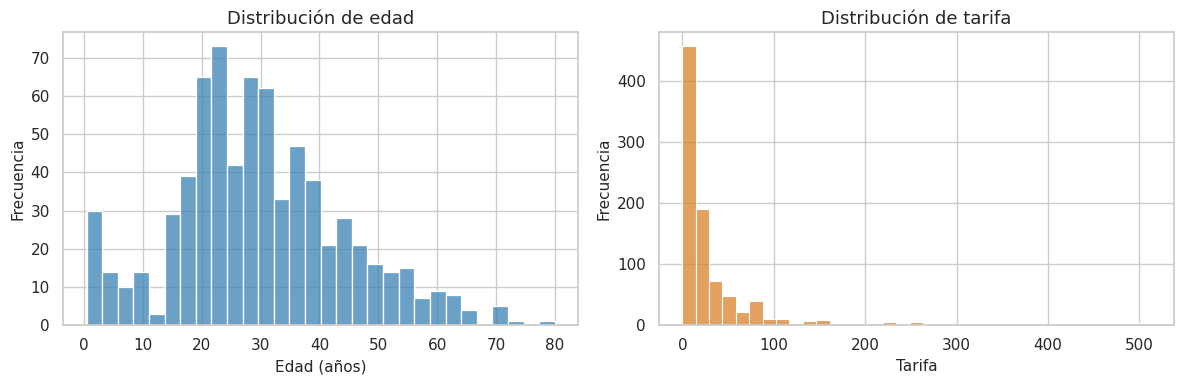

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=titanic, x="age", bins=30, ax=axes[0], color="#3B82B5")
axes[0].set_title("Distribución de edad")
axes[0].set_xlabel("Edad (años)")
axes[0].set_ylabel("Frecuencia")

sns.histplot(data=titanic, x="fare", bins=35, ax=axes[1], color="#D9822B")
axes[1].set_title("Distribución de tarifa")
axes[1].set_xlabel("Tarifa")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()


**Figura 3. Proporción de supervivencia por sexo registrado y clase.**  
**Tabla 8. Tasas y tamaños de los grupos representados en la Figura 3.**


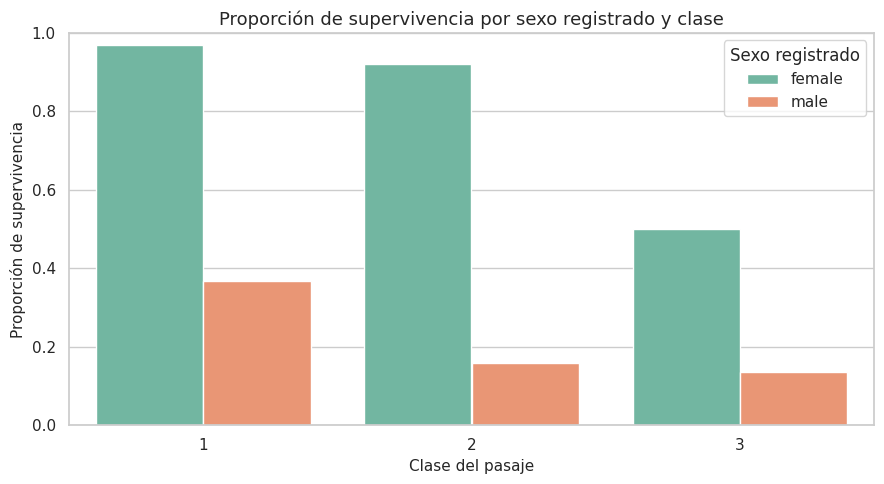

,sex,pclass,tasa_supervivencia,registros,tasa_supervivencia_pct
0,female,1,0.968085,94,96.8
1,female,2,0.921053,76,92.1
2,female,3,0.500000,144,50.0
3,male,1,0.368852,122,36.9
4,male,2,0.157407,108,15.7
5,male,3,0.135447,347,13.5


In [14]:
tasas_grupo = (
    titanic.groupby(["sex", "pclass"], as_index=False, dropna=False)["survived"]
    .agg(tasa_supervivencia="mean", registros="size")
)

ax = sns.barplot(
    data=tasas_grupo,
    x="pclass",
    y="tasa_supervivencia",
    hue="sex",
    palette="Set2",
)
ax.set_title("Proporción de supervivencia por sexo registrado y clase")
ax.set_xlabel("Clase del pasaje")
ax.set_ylabel("Proporción de supervivencia")
ax.set_ylim(0, 1)
ax.legend(title="Sexo registrado")

plt.tight_layout()
plt.show()

tasas_grupo.assign(
    tasa_supervivencia_pct=lambda x: (x["tasa_supervivencia"] * 100).round(1)
)


In [15]:
tasa_global = titanic["survived"].mean()

display(Markdown(
    f"""
### Lectura preliminar de las salidas

- La muestra contiene **{len(titanic)} registros** y la supervivencia observada alcanza **{tasa_global:.1%}**.
- `fare` presenta una distribución marcadamente asimétrica hacia valores altos. Antes de comparar grupos habrá que revisar su escala y sus valores extremos.
- `age` permite una exploración relevante, pero su **{titanic['age'].isna().mean():.1%} de datos faltantes** obliga a informar el número de casos válidos en cada comparación.
- La visualización por sexo registrado y clase muestra diferencias descriptivas entre grupos. Estas diferencias orientan la siguiente fase, pero no bastan para establecer causalidad ni generalizar fuera del dataset.
- La alta ausencia de `deck` (**{titanic['deck'].isna().mean():.1%}**) limita su uso y exige evaluar si aporta información suficiente antes de incorporarla al análisis principal.
"""
))



### Lectura preliminar de las salidas

- La muestra contiene **891 registros** y la supervivencia observada alcanza **38.4%**.
- `fare` presenta una distribución marcadamente asimétrica hacia valores altos. Antes de comparar grupos habrá que revisar su escala y sus valores extremos.
- `age` permite una exploración relevante, pero su **19.9% de datos faltantes** obliga a informar el número de casos válidos en cada comparación.
- La visualización por sexo registrado y clase muestra diferencias descriptivas entre grupos. Estas diferencias orientan la siguiente fase, pero no bastan para establecer causalidad ni generalizar fuera del dataset.
- La alta ausencia de `deck` (**77.2%**) limita su uso y exige evaluar si aporta información suficiente antes de incorporarla al análisis principal.


## 11. Transformaciones realizadas

Las transformaciones se aplican sobre `titanic_eda`, mientras `titanic_raw` y `titanic` conservan los datos cargados. Se selecciona una representación por concepto y se crean `family_size`, `family_context` y `age_group`. Los cortes etarios permanecen visibles en el código y no imputan edades ausentes.

**Tabla 9. Registro completo de transformaciones.**


In [16]:
COLUMNAS_ANALISIS = [
    "survived", "pclass", "sex", "age", "sibsp", "parch",
    "fare", "embark_town", "alone",
]

titanic_eda = titanic[COLUMNAS_ANALISIS].copy()
titanic_eda["family_size"] = titanic_eda["sibsp"] + titanic_eda["parch"] + 1
titanic_eda["family_context"] = pd.Categorical(
    np.where(titanic_eda["family_size"].eq(1), "Viaja solo", "Viaja con familiares"),
    categories=["Viaja solo", "Viaja con familiares"],
    ordered=True,
)
titanic_eda["age_group"] = pd.cut(
    titanic_eda["age"],
    bins=[0, 12, 17, 59, np.inf],
    labels=["Niñez (0-12)", "Adolescencia (13-17)", "Adultez (18-59)", "60 años o más"],
    include_lowest=True,
)

registro_transformaciones = pd.DataFrame([
    (1, "sns.load_dataset('titanic')", "Carga directa desde Seaborn", "titanic_raw", 891, 15, "No"),
    (2, "titanic_raw", "Copia profunda", "titanic", len(titanic), titanic.shape[1], "No"),
    (3, "titanic", "Selección de una representación por concepto", "titanic_eda", len(titanic_eda), 9, "Solo columnas"),
    (4, "sibsp, parch", "family_size = sibsp + parch + 1", "titanic_eda", len(titanic_eda), 10, "Añade columna"),
    (5, "family_size", "Clasificación solo / con familiares", "titanic_eda", len(titanic_eda), 11, "Añade columna"),
    (6, "age", "Tramos [0-12], [13-17], [18-59], [60+]", "titanic_eda", len(titanic_eda), 12, "Añade columna"),
], columns=["Paso", "Entrada", "Operación", "Salida", "Filas", "Columnas", "Efecto"])

registro_transformaciones


,Paso,Entrada,Operación,Salida,Filas,Columnas,Efecto
0,1,sns.load_dataset('titanic'),Carga directa desde Seaborn,titanic_raw,891,15,No
1,2,titanic_raw,Copia profunda,titanic,891,15,No
2,3,titanic,Selección de una representación por concepto,titanic_eda,891,9,Solo columnas
3,4,"sibsp, parch",family_size = sibsp + parch + 1,titanic_eda,891,10,Añade columna
4,5,family_size,Clasificación solo / con familiares,titanic_eda,891,11,Añade columna
5,6,age,"Tramos [0-12], [13-17], [18-59], [60+]",titanic_eda,891,12,Añade columna


**Tabla 10. Resultados intermedios de las transformaciones.**


In [17]:
# Resultados intermedios de las transformaciones.
resultado_transformaciones = pd.Series({
    "Filas de entrada": len(titanic),
    "Filas de salida": len(titanic_eda),
    "Columnas de la vista analítica": titanic_eda.shape[1],
    "Edades válidas": titanic_eda["age"].notna().sum(),
    "Tramos etarios ausentes": titanic_eda["age_group"].isna().sum(),
}, name="Resultado")

resultado_transformaciones.to_frame().round(3)


,Resultado
Filas de entrada,891
Filas de salida,891
Columnas de la vista analítica,12
Edades válidas,714
Tramos etarios ausentes,177


## 12. Resultados e interpretación inicial

Para mantener un procedimiento uniforme se utiliza una función que calcula cantidad de registros, supervivientes y tasa observada por grupo. La modularización evita repetir cálculos con lógicas diferentes entre preguntas (Rule et al., 2019). Las agrupaciones se realizan con `groupby` de pandas (The pandas development team, 2026).


In [18]:
def resumen_supervivencia(df: pd.DataFrame, grupos: list[str]) -> pd.DataFrame:
    '''Devuelve tamaño, supervivientes y tasa observada por grupo.'''
    resultado = (
        df.groupby(grupos, dropna=False, observed=True)["survived"]
        .agg(registros="size", supervivientes="sum", tasa_supervivencia="mean")
        .reset_index()
    )
    resultado["tasa_pct"] = (resultado["tasa_supervivencia"] * 100).round(1)
    return resultado


print("Función de resumen creada correctamente.")


Función de resumen creada correctamente.


### 12.1 Pregunta 1: supervivencia por sexo registrado y clase

La primera aproximación se encuentra en la **Tabla 8** y la **Figura 3**, donde se calcularon las tasas para cada combinación de `sex` y `pclass`. A continuación se recuperan los valores necesarios para dejar una interpretación calculada desde los datos.

**Tabla 11. Supervivencia observada por sexo registrado y clase.**


In [19]:
tabla_p1 = resumen_supervivencia(titanic_eda, ["sex", "pclass"])
tabla_p1[["sex", "pclass", "registros", "supervivientes", "tasa_pct"]]


,sex,pclass,registros,supervivientes,tasa_pct
0,female,1,94,91,96.8
1,female,2,76,70,92.1
2,female,3,144,72,50.0
3,male,1,122,45,36.9
4,male,2,108,17,15.7
5,male,3,347,47,13.5


In [20]:
p1_f_primera = tabla_p1.query("sex == 'female' and pclass == 1")["tasa_supervivencia"].iloc[0]
p1_m_tercera = tabla_p1.query("sex == 'male' and pclass == 3")["tasa_supervivencia"].iloc[0]

display(Markdown(f'''
**Resultado e interpretación P1.** La mayor tasa se observa en el grupo `female` de primera clase (**{p1_f_primera:.1%}; n=94**) y la menor en `male` de tercera clase (**{p1_m_tercera:.1%}; n=347**). La dirección de la diferencia por sexo se mantiene en las tres clases, mientras que la magnitud también cambia por clase. Esto responde P1 de manera descriptiva, pero no aísla efectos causales ni controla simultáneamente edad u otras variables.
'''))



**Resultado e interpretación P1.** La mayor tasa se observa en el grupo `female` de primera clase (**96.8%; n=94**) y la menor en `male` de tercera clase (**13.5%; n=347**). La dirección de la diferencia por sexo se mantiene en las tres clases, mientras que la magnitud también cambia por clase. Esto responde P1 de manera descriptiva, pero no aísla efectos causales ni controla simultáneamente edad u otras variables.


### 12.2 Pregunta 2: edad y supervivencia

Se comparan los casos válidos, la media, la mediana y el rango intercuartílico entre quienes sobrevivieron y quienes no. Luego se revisan tasas por tramo etario sin imputar las 177 edades ausentes.

**Tabla 12. Distribución de edad según supervivencia.**


In [21]:
tabla_p2_edad = (
    titanic_eda.groupby("survived", observed=True)["age"]
    .agg(validos="count", media="mean", mediana="median", desviacion="std")
)
cuartiles_edad = (
    titanic_eda.groupby("survived", observed=True)["age"]
    .quantile([0.25, 0.75]).unstack()
    .rename(columns={0.25: "q1", 0.75: "q3"})
)
tabla_p2_edad = tabla_p2_edad.join(cuartiles_edad).reset_index()
tabla_p2_edad.round(2)


,survived,validos,media,mediana,desviacion,q1,q3
0,0,424,30.63,28.0,14.17,21.0,39.0
1,1,290,28.34,28.0,14.95,19.0,36.0


**Tabla 13. Supervivencia observada por tramo etario.**  
*Nota.* Los cortes son operativos para esta exploración y no constituyen una clasificación universal.


In [22]:
tabla_p2_tramo = resumen_supervivencia(
    titanic_eda.dropna(subset=["age_group"]), ["age_group"]
)
tabla_p2_tramo[["age_group", "registros", "supervivientes", "tasa_pct"]]


,age_group,registros,supervivientes,tasa_pct
0,Niñez (0-12),69,40,58.0
1,Adolescencia (13-17),44,21,47.7
2,Adultez (18-59),575,222,38.6
3,60 años o más,26,7,26.9


**Figura 4. Edad según supervivencia y tasa por tramo etario.**


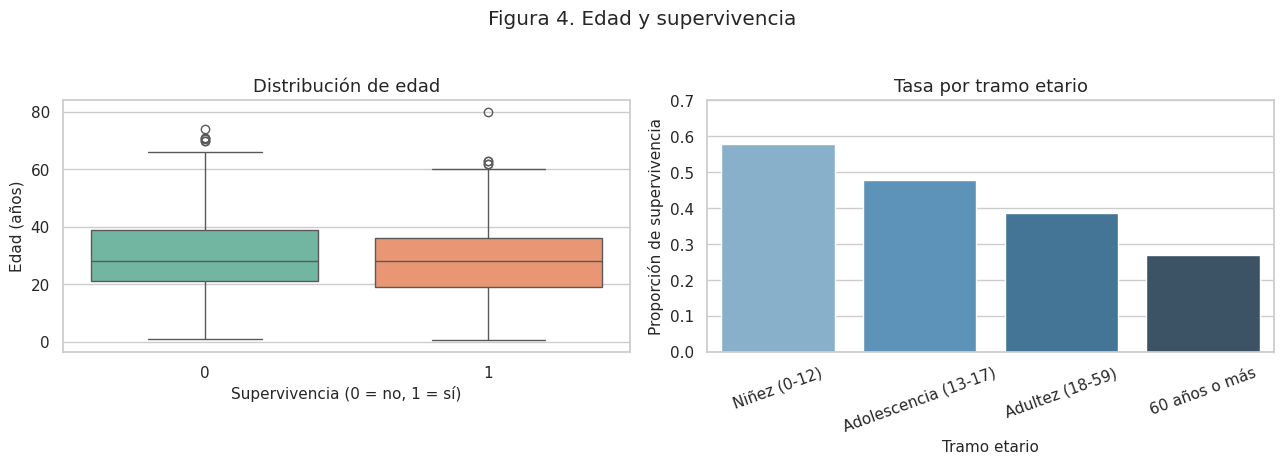

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=titanic_eda, x="survived", y="age", hue="survived", legend=False, ax=axes[0], palette="Set2")
axes[0].set_title("Distribución de edad")
axes[0].set_xlabel("Supervivencia (0 = no, 1 = sí)")
axes[0].set_ylabel("Edad (años)")

sns.barplot(data=tabla_p2_tramo, x="age_group", y="tasa_supervivencia", hue="age_group", legend=False, ax=axes[1], palette="Blues_d")
axes[1].set_title("Tasa por tramo etario")
axes[1].set_xlabel("Tramo etario")
axes[1].set_ylabel("Proporción de supervivencia")
axes[1].set_ylim(0, 0.7)
axes[1].tick_params(axis="x", rotation=20)

fig.suptitle("Figura 4. Edad y supervivencia", y=1.03)
plt.tight_layout()
plt.show()


In [24]:
mediana_no = tabla_p2_edad.query("survived == 0")["mediana"].iloc[0]
mediana_si = tabla_p2_edad.query("survived == 1")["mediana"].iloc[0]
tasa_ninez = tabla_p2_tramo.loc[tabla_p2_tramo["age_group"].eq("Niñez (0-12)"), "tasa_supervivencia"].iloc[0]
tasa_mayores = tabla_p2_tramo.loc[tabla_p2_tramo["age_group"].eq("60 años o más"), "tasa_supervivencia"].iloc[0]

display(Markdown(f'''
**Resultado e interpretación P2.** La mediana de edad es **{mediana_no:.1f} años** entre quienes no sobrevivieron y **{mediana_si:.1f} años** entre quienes sobrevivieron; por sí sola, la mediana no muestra una separación. Al agrupar, la tasa desciende desde **{tasa_ninez:.1%} (n=69)** en niñez hasta **{tasa_mayores:.1%} (n=26)** en el tramo de 60 años o más. Esta lectura usa **714 casos con edad registrada** y puede cambiar si la ausencia de edad no es aleatoria.
'''))



**Resultado e interpretación P2.** La mediana de edad es **28.0 años** entre quienes no sobrevivieron y **28.0 años** entre quienes sobrevivieron; por sí sola, la mediana no muestra una separación. Al agrupar, la tasa desciende desde **58.0% (n=69)** en niñez hasta **26.9% (n=26)** en el tramo de 60 años o más. Esta lectura usa **714 casos con edad registrada** y puede cambiar si la ausencia de edad no es aleatoria.


### 12.3 Pregunta 3: tarifa, clase y supervivencia

Se comparan la mediana y el rango intercuartílico de `fare` por clase y supervivencia. La tarifa se conserva en su escala original, lo que permite interpretar directamente los valores y mantener visibles los valores altos observados en el conjunto de datos.

**Tabla 14. Tarifa por clase y supervivencia.**


In [25]:
tabla_p3 = (
    titanic_eda.groupby(["pclass", "survived"], observed=True)["fare"]
    .agg(registros="size", media="mean", mediana="median")
)
cuartiles_fare = (
    titanic_eda.groupby(["pclass", "survived"], observed=True)["fare"]
    .quantile([0.25, 0.75]).unstack()
    .rename(columns={0.25: "q1", 0.75: "q3"})
)
tabla_p3 = tabla_p3.join(cuartiles_fare).reset_index()
tabla_p3.round(2)


,pclass,survived,registros,media,mediana,q1,q3
0,1,0,80,64.68,44.75,27.74,78.94
1,1,1,136,95.61,77.96,50.99,111.48
2,2,0,97,19.41,13.00,11.50,26.00
3,2,1,87,22.06,21.00,13.00,26.25
4,3,0,372,13.67,8.05,7.75,15.14
5,3,1,119,13.69,8.52,7.78,15.88


**Figura 5. Tarifa por clase y supervivencia.**  
*Nota.* El diagrama utiliza `fare` en su escala original y mantiene visibles los valores extremos.


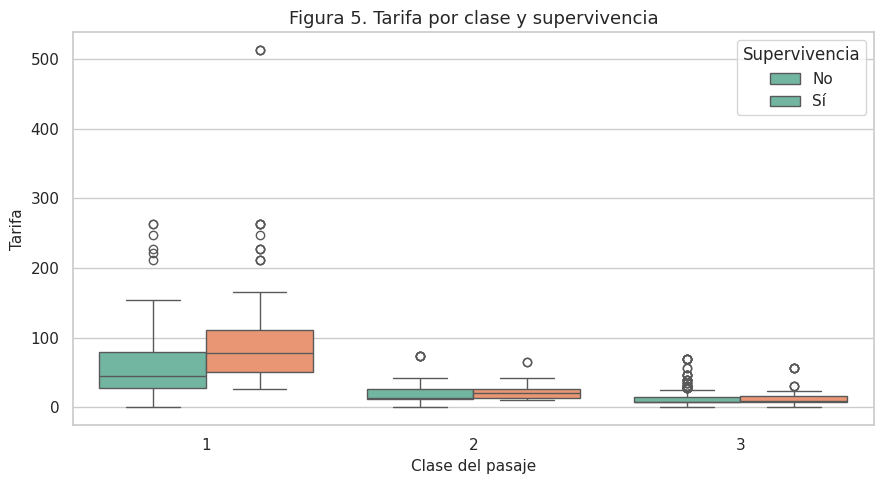

In [26]:
ax = sns.boxplot(
    data=titanic_eda,
    x="pclass",
    y="fare",
    hue="survived",
    palette="Set2",
)
ax.set_title("Figura 5. Tarifa por clase y supervivencia")
ax.set_xlabel("Clase del pasaje")
ax.set_ylabel("Tarifa")
ax.legend(title="Supervivencia", labels=["No", "Sí"])
plt.tight_layout()
plt.show()


In [27]:
mediana_p1_no = tabla_p3.query("pclass == 1 and survived == 0")["mediana"].iloc[0]
mediana_p1_si = tabla_p3.query("pclass == 1 and survived == 1")["mediana"].iloc[0]
mediana_p3_no = tabla_p3.query("pclass == 3 and survived == 0")["mediana"].iloc[0]
mediana_p3_si = tabla_p3.query("pclass == 3 and survived == 1")["mediana"].iloc[0]

display(Markdown(f'''
**Resultado e interpretación P3.** En primera clase, la mediana de tarifa es **{mediana_p1_si:.2f}** entre supervivientes y **{mediana_p1_no:.2f}** entre no supervivientes; en tercera clase las medianas son próximas (**{mediana_p3_si:.2f}** y **{mediana_p3_no:.2f}**, respectivamente). La relación tarifa-supervivencia no es uniforme entre clases. Como `fare` también refleja clase, tamaño del ticket u otras condiciones no observadas, no se interpreta como causa independiente.
'''))



**Resultado e interpretación P3.** En primera clase, la mediana de tarifa es **77.96** entre supervivientes y **44.75** entre no supervivientes; en tercera clase las medianas son próximas (**8.52** y **8.05**, respectivamente). La relación tarifa-supervivencia no es uniforme entre clases. Como `fare` también refleja clase, tamaño del ticket u otras condiciones no observadas, no se interpreta como causa independiente.


### 12.4 Pregunta 4: viajar solo o con familiares

Se utiliza `family_size = sibsp + parch + 1` para distinguir entre quienes aparecen viajando solos y quienes tienen familiares registrados a bordo. La correspondencia con `alone` se comprobará nuevamente en los controles finales.

**Tabla 15. Supervivencia observada según contexto familiar.**


In [28]:
tabla_p4 = resumen_supervivencia(titanic_eda, ["family_context"])
tabla_p4[["family_context", "registros", "supervivientes", "tasa_pct"]]


,family_context,registros,supervivientes,tasa_pct
0,Viaja solo,537,163,30.4
1,Viaja con familiares,354,179,50.6


**Figura 6. Proporción de supervivencia según contexto familiar.**


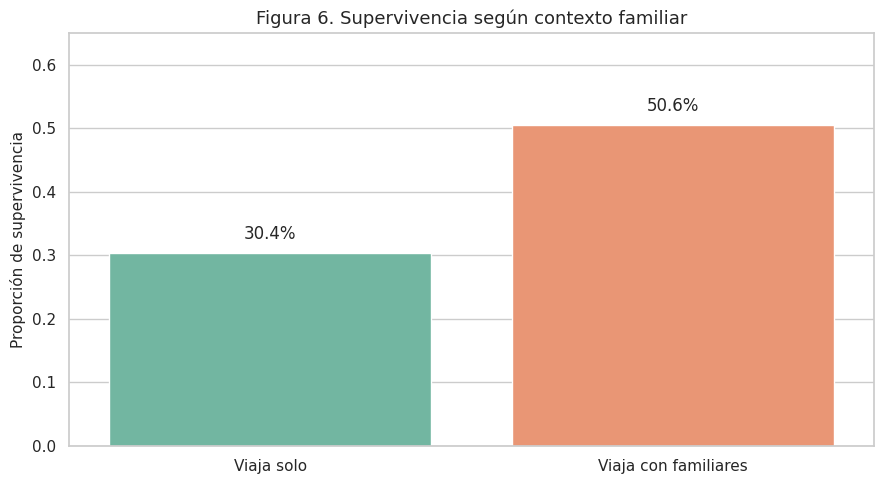

In [29]:
ax = sns.barplot(
    data=tabla_p4,
    x="family_context",
    y="tasa_supervivencia",
    hue="family_context",
    legend=False,
    palette="Set2",
)
ax.set_title("Figura 6. Supervivencia según contexto familiar")
ax.set_xlabel("")
ax.set_ylabel("Proporción de supervivencia")
ax.set_ylim(0, 0.65)
for barra in ax.patches:
    altura = barra.get_height()
    if np.isfinite(altura):
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            altura + 0.015,
            f"{altura:.1%}",
            ha="center",
            va="bottom",
        )
plt.tight_layout()
plt.show()


In [30]:
tasa_solo = tabla_p4.loc[tabla_p4["family_context"].eq("Viaja solo"), "tasa_supervivencia"].iloc[0]
tasa_familia = tabla_p4.loc[tabla_p4["family_context"].eq("Viaja con familiares"), "tasa_supervivencia"].iloc[0]

display(Markdown(f'''
**Resultado e interpretación P4.** Quienes figuran viajando con familiares presentan una tasa de **{tasa_familia:.1%} (n=354)**, frente a **{tasa_solo:.1%} (n=537)** entre quienes viajan solos. La diferencia responde P4 dentro de la muestra, pero la variable aproxima acompañamiento familiar registrado y no identifica hogares, amistades, empleados ni tickets compartidos.
'''))



**Resultado e interpretación P4.** Quienes figuran viajando con familiares presentan una tasa de **50.6% (n=354)**, frente a **30.4% (n=537)** entre quienes viajan solos. La diferencia responde P4 dentro de la muestra, pero la variable aproxima acompañamiento familiar registrado y no identifica hogares, amistades, empleados ni tickets compartidos.


### 12.5 Pregunta 5: puerto de embarque, clase y supervivencia

Se calculan tasas por puerto y clase. La estratificación permite revisar el puerto junto con la composición por clase. Los dos registros sin puerto se excluyen únicamente de esta comparación.

**Tabla 16. Supervivencia observada por puerto de embarque y clase.**


In [31]:
tabla_p5 = resumen_supervivencia(
    titanic_eda.dropna(subset=["embark_town"]), ["embark_town", "pclass"]
)
tabla_p5[["embark_town", "pclass", "registros", "supervivientes", "tasa_pct"]]


,embark_town,pclass,registros,supervivientes,tasa_pct
0,Cherbourg,1,85,59,69.4
1,Cherbourg,2,17,9,52.9
2,Cherbourg,3,66,25,37.9
3,Queenstown,1,2,1,50.0
4,Queenstown,2,3,2,66.7
5,Queenstown,3,72,27,37.5
6,Southampton,1,127,74,58.3
7,Southampton,2,164,76,46.3
8,Southampton,3,353,67,19.0


**Figura 7. Tasa de supervivencia por puerto de embarque y clase.**  
*Nota.* Cada celda muestra el porcentaje observado y el tamaño del grupo.


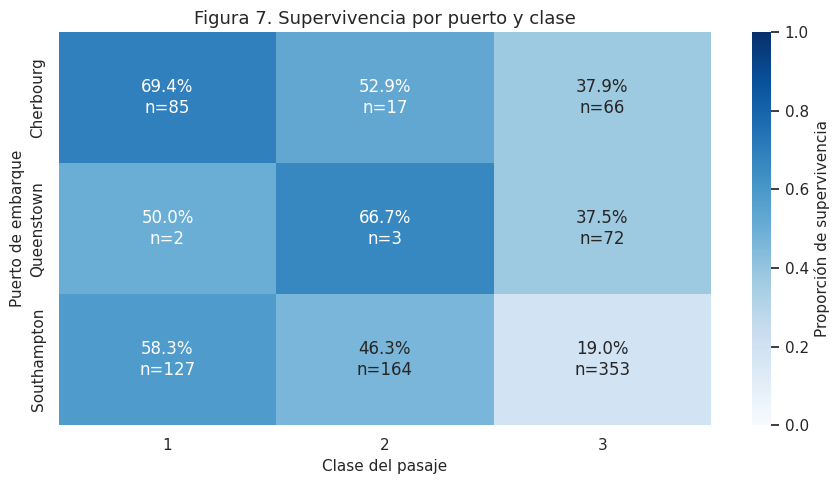

In [32]:
matriz_tasa = tabla_p5.pivot(index="embark_town", columns="pclass", values="tasa_supervivencia")
matriz_n = tabla_p5.pivot(index="embark_town", columns="pclass", values="registros")
anotaciones = matriz_tasa.copy().astype(object)
for puerto in matriz_tasa.index:
    for clase in matriz_tasa.columns:
        anotaciones.loc[puerto, clase] = f"{matriz_tasa.loc[puerto, clase]:.1%}\nn={int(matriz_n.loc[puerto, clase])}"

ax = sns.heatmap(
    matriz_tasa,
    annot=anotaciones,
    fmt="",
    cmap="Blues",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Proporción de supervivencia"},
)
ax.set_title("Figura 7. Supervivencia por puerto y clase")
ax.set_xlabel("Clase del pasaje")
ax.set_ylabel("Puerto de embarque")
plt.tight_layout()
plt.show()


In [33]:
tasa_c1 = tabla_p5.query("embark_town == 'Cherbourg' and pclass == 1")["tasa_supervivencia"].iloc[0]
tasa_s1 = tabla_p5.query("embark_town == 'Southampton' and pclass == 1")["tasa_supervivencia"].iloc[0]
tasa_c3 = tabla_p5.query("embark_town == 'Cherbourg' and pclass == 3")["tasa_supervivencia"].iloc[0]
tasa_s3 = tabla_p5.query("embark_town == 'Southampton' and pclass == 3")["tasa_supervivencia"].iloc[0]

display(Markdown(f'''
**Resultado e interpretación P5.** Dentro de primera clase, Cherbourg registra **{tasa_c1:.1%} (n=85)** y Southampton **{tasa_s1:.1%} (n=127)**; dentro de tercera clase, las tasas son **{tasa_c3:.1%} (n=66)** y **{tasa_s3:.1%} (n=353)**. Aunque persisten diferencias dentro de estas clases, los grupos de Queenstown en primera (n=2) y segunda clase (n=3) son demasiado pequeños para comparaciones estables. El puerto puede resumir otras diferencias no medidas y no debe tratarse como causa.
'''))



**Resultado e interpretación P5.** Dentro de primera clase, Cherbourg registra **69.4% (n=85)** y Southampton **58.3% (n=127)**; dentro de tercera clase, las tasas son **37.9% (n=66)** y **19.0% (n=353)**. Aunque persisten diferencias dentro de estas clases, los grupos de Queenstown en primera (n=2) y segunda clase (n=3) son demasiado pequeños para comparaciones estables. El puerto puede resumir otras diferencias no medidas y no debe tratarse como causa.


## 13. Registro consolidado de decisiones exploratorias

Una vez completadas las transformaciones y las respuestas a las cinco preguntas, se consolida el registro de las decisiones adoptadas durante todo el avance. Para cada decisión se identifica su justificación, el resultado intermedio que produjo y su estado, permitiendo reconstruir cómo evolucionó el análisis desde la carga de datos hasta la interpretación de los hallazgos (Rule et al., 2019).

**Tabla 17. Bitácora consolidada de decisiones exploratorias.**


In [34]:
registro_decisiones = pd.DataFrame([
    ("D01", "Conservar `titanic_raw` y trabajar sobre copias.", "Mantener una referencia inalterada.", "Se creó la copia de trabajo `titanic`.", "Aplicada"),
    ("D02", "Validar 891 filas, 15 columnas y esquema esperado.", "Detectar cambios de la fuente antes del EDA.", "Las aserciones fueron superadas.", "Aplicada"),
    ("D03", "No eliminar las 107 filas iguales.", "No existe identificador para confirmar duplicados reales.", "Se conservaron 891 filas.", "Aplicada"),
    ("D04", "No imputar valores faltantes.", "La estrategia depende de la pregunta y del patrón de ausencia.", "P2 usa 714 edades válidas; P5 omite 2 puertos ausentes.", "Aplicada"),
    ("D05", "Excluir redundancias de la vista analítica.", "Evitar doble conteo y fuga de información.", "No se usan `alive`, `class` ni `embarked` en los resultados.", "Aplicada"),
    ("D06", "Excluir `deck` de las preguntas actuales.", "Su ausencia alcanza 77,2%.", "Se conserva solo en la fuente.", "Aplicada"),
    ("D07", "Derivar `family_size` y `family_context`.", "Responder P4 con una definición verificable.", "Se añadieron dos columnas sin perder filas.", "Aplicada"),
    ("D08", "Crear tramos etarios fijos sin imputar.", "Comparar grupos interpretables y conservar la ausencia.", "714 registros tienen tramo y 177 permanecen ausentes.", "Aplicada"),
    ("D09", "Informar tamaños junto con tasas.", "Evitar interpretar porcentajes sin denominador.", "Todas las respuestas incluyen `registros`.", "Aplicada"),
    ("D10", "Separar descripción de causalidad.", "Los datos son observacionales y adaptados.", "Las conclusiones se formulan como asociaciones.", "Aplicada"),
], columns=["ID", "Decisión", "Justificación", "Resultado intermedio", "Estado"])

registro_decisiones


,ID,Decisión,Justificación,Resultado intermedio,Estado
0,D01,Conservar `titanic_raw` y trabajar sobre copias.,Mantener una referencia inalterada.,Se creó la copia de trabajo `titanic`.,Aplicada
1,D02,"Validar 891 filas, 15 columnas y esquema esper...",Detectar cambios de la fuente antes del EDA.,Las aserciones fueron superadas.,Aplicada
2,D03,No eliminar las 107 filas iguales.,No existe identificador para confirmar duplica...,Se conservaron 891 filas.,Aplicada
3,D04,No imputar valores faltantes.,La estrategia depende de la pregunta y del pat...,P2 usa 714 edades válidas; P5 omite 2 puertos ...,Aplicada
4,D05,Excluir redundancias de la vista analítica.,Evitar doble conteo y fuga de información.,"No se usan `alive`, `class` ni `embarked` en l...",Aplicada
5,D06,Excluir `deck` de las preguntas actuales.,"Su ausencia alcanza 77,2%.",Se conserva solo en la fuente.,Aplicada
6,D07,Derivar `family_size` y `family_context`.,Responder P4 con una definición verificable.,Se añadieron dos columnas sin perder filas.,Aplicada
7,D08,Crear tramos etarios fijos sin imputar.,Comparar grupos interpretables y conservar la ...,714 registros tienen tramo y 177 permanecen au...,Aplicada
8,D09,Informar tamaños junto con tasas.,Evitar interpretar porcentajes sin denominador.,Todas las respuestas incluyen `registros`.,Aplicada
9,D10,Separar descripción de causalidad.,Los datos son observacionales y adaptados.,Las conclusiones se formulan como asociaciones.,Aplicada


## 14. Trazabilidad entre preguntas, acciones y resultados

La síntesis siguiente vincula cada pregunta con la acción realizada, la evidencia generada, el hallazgo inicial y la principal cautela interpretativa.

**Tabla 18. Correspondencia entre preguntas, acciones y resultados.**


In [35]:
matriz_trazabilidad = pd.DataFrame([
    ("P1", "Agrupar por sexo y clase", "Tabla 11; Figura 3", f"96,8% en female-1.ª frente a 13,5% en male-3.ª.", "No controla edad ni otros factores."),
    ("P2", "Comparar edad y tramos", "Tablas 12-13; Figura 4", f"Medianas iguales a 28; tasas 58,0% en niñez y 26,9% en 60+.", "Solo 714 edades válidas; cortes operativos."),
    ("P3", "Resumir tarifa por clase", "Tabla 14; Figura 5", f"En 1.ª, mediana 77,96 (sí) frente a 44,75 (no); en 3.ª son próximas.", "Tarifa y clase están relacionadas."),
    ("P4", "Derivar contexto familiar", "Tabla 15; Figura 6", f"50,6% con familiares frente a 30,4% solos.", "No identifica todos los vínculos a bordo."),
    ("P5", "Estratificar puerto por clase", "Tabla 16; Figura 7", f"Las tasas varían por puerto dentro de 1.ª y 3.ª clase.", "Dos puertos ausentes y estratos pequeños en Queenstown."),
], columns=["Pregunta", "Acción", "Evidencia", "Hallazgo inicial", "Cautela"])

matriz_trazabilidad


,Pregunta,Acción,Evidencia,Hallazgo inicial,Cautela
0,P1,Agrupar por sexo y clase,Tabla 11; Figura 3,"96,8% en female-1.ª frente a 13,5% en male-3.ª.",No controla edad ni otros factores.
1,P2,Comparar edad y tramos,Tablas 12-13; Figura 4,"Medianas iguales a 28; tasas 58,0% en niñez y ...",Solo 714 edades válidas; cortes operativos.
2,P3,Resumir tarifa por clase,Tabla 14; Figura 5,"En 1.ª, mediana 77,96 (sí) frente a 44,75 (no)...",Tarifa y clase están relacionadas.
3,P4,Derivar contexto familiar,Tabla 15; Figura 6,"50,6% con familiares frente a 30,4% solos.",No identifica todos los vínculos a bordo.
4,P5,Estratificar puerto por clase,Tabla 16; Figura 7,Las tasas varían por puerto dentro de 1.ª y 3....,Dos puertos ausentes y estratos pequeños en Qu...


## 15. Organización del EDA implementado

El trabajo siguió una secuencia acumulativa. Cada etapa utilizó las evidencias de la anterior y añadió una interpretación o decisión asociada al código que produjo el resultado.

| Etapa | Actividad implementada | Evidencia obtenida |
|---|---|---|
| 1. Validación de entrada | Se confirmó la fuente, el esquema, las dimensiones y la unidad de análisis. | Aserciones de estructura, vista inicial y diccionario de variables. |
| 2. Calidad de datos | Se revisaron faltantes, filas iguales, tipos, categorías y variables redundantes. | Perfil de calidad y controles de coherencia. |
| 3. Preparación exploratoria | Se creó una vista analítica sin modificar los datos cargados. | Registro de transformaciones y variables derivadas. |
| 4. Análisis univariado | Se examinaron distribuciones, tendencia central, dispersión y asimetría. | Estadísticos descriptivos y Figuras 1 y 2. |
| 5. Análisis bivariado | Se comparó la supervivencia según sexo, clase, edad, tarifa, contexto familiar y puerto. | Tablas 11–16 y Figuras 3, 4, 5, 6 y 7. |
| 6. Síntesis | Se vinculó cada pregunta con su acción, evidencia, hallazgo y cautela. | Matriz de trazabilidad de la sección 14. |

La secuencia aplicada mantiene el patrón **pregunta → código → resultado → interpretación → cautela**, permitiendo seguir el razonamiento y repetir el análisis (Rule et al., 2019).


## 16. Criterios de trabajo reproducible aplicados

- El notebook se ejecuta completo y en orden antes de compartir una versión (Rule et al., 2019).
- Las versiones de las librerías y las validaciones automáticas del esquema permanecen visibles.
- `titanic_raw` conserva los datos cargados y los cambios se aplican sobre copias con nombres explícitos.
- Cada selección o variable derivada queda documentada en el registro de transformaciones.
- Las salidas relevantes se acompañan de una interpretación que diferencia observaciones, supuestos y decisiones.
- Los resultados numéricos utilizados en las interpretaciones se obtienen desde el código y no se calculan manualmente.
- Las comparaciones informan el número de registros para evitar interpretar porcentajes sin conocer su denominador.
- Las ausencias, los grupos pequeños y los resultados inesperados se mantienen visibles y se incorporan a las limitaciones.
- El archivo utiliza un nombre sin tildes ni caracteres especiales y puede ejecutarse directamente en Google Colab.


## 17. Supuestos y limitaciones del avance

- Cada fila se trata como un registro de pasajero, aunque esta versión no posee un identificador que permita verificar su particularidad.
- `survived` se interpreta como el resultado binario observado; `alive` se excluye de la vista analítica porque contiene la misma información.
- Las tasas se calculan sobre los registros disponibles. Las comparaciones de edad utilizan 714 casos y las de puerto 889; no se supone que la ausencia sea aleatoria.
- Las 107 filas exactamente iguales se conservan porque, sin identificador, nombre ni ticket, no es posible concluir que correspondan a duplicados reales.
- `family_size` representa a la persona más `sibsp` y `parch`; aproxima el contexto familiar, pero no identifica todos los grupos o vínculos de viaje.
- Los tramos etarios son cortes exploratorios explícitos y revisables, no una clasificación universal.
- `fare` se conserva en su escala original; sus valores altos permanecen visibles y no se eliminan automáticamente.
- `deck` no se incorpora a las preguntas por presentar 77,2% de ausencia.
- El dataset es una copia adaptada para ejemplos de Seaborn y no contiene todas las variables disponibles en otras versiones del Titanic (Waskom, s. f.).
- Los patrones encontrados describen los registros observados. No prueban relaciones causales ni deben generalizarse automáticamente a otras poblaciones.


## 18. Control final de reproducibilidad y coherencia

El notebook debe abrirse en Google Colab y ejecutarse mediante **Entorno de ejecución → Ejecutar todas**. No requiere cargar archivos manualmente. Los controles comprueban la entrada, la conservación de filas, las variables derivadas y la existencia de evidencia para las cinco preguntas. Reiniciar el entorno y ejecutar todas las celdas permite detectar dependencias ocultas (Rule et al., 2019).

**Tabla 19. Controles finales de reproducibilidad.**


In [36]:
control_final = pd.Series({
    "Fuente conserva 891 x 15": titanic_raw.shape == (891, 15),
    "Columnas de entrada esperadas": titanic_raw.columns.tolist() == COLUMNAS_ESPERADAS,
    "Copia base coincide con la entrada": titanic.equals(titanic_raw),
    "Vista analítica conserva 891 filas": len(titanic_eda) == len(titanic_raw),
    "family_size respeta la fórmula": titanic_eda["family_size"].eq(titanic_eda["sibsp"] + titanic_eda["parch"] + 1).all(),
    "family_context coincide con alone": titanic_eda["family_context"].eq(
        np.where(titanic_eda["alone"], "Viaja solo", "Viaja con familiares")
    ).all(),
    "Ausencia de tramo coincide con age": titanic_eda["age_group"].isna().eq(titanic_eda["age"].isna()).all(),
    "Redundancias verificadas": bool(controles_coherencia.all()),
    "Cinco preguntas tienen evidencia": set(matriz_trazabilidad["Pregunta"]) == {"P1", "P2", "P3", "P4", "P5"},
    "Bitácora completa": registro_decisiones["Resultado intermedio"].notna().all(),
}, name="Cumple")

assert control_final.all(), "Uno o más controles de reproducibilidad fallaron."
control_final.to_frame()


,Cumple
Fuente conserva 891 x 15,True
Columnas de entrada esperadas,True
Copia base coincide con la entrada,True
Vista analítica conserva 891 filas,True
family_size respeta la fórmula,True
family_context coincide con alone,True
Ausencia de tramo coincide con age,True
Redundancias verificadas,True
Cinco preguntas tienen evidencia,True
Bitácora completa,True


In [37]:
display(Markdown(f'''
**Resultado del control.** Se superaron **{int(control_final.sum())} de {len(control_final)} verificaciones**. La entrada permanece intacta, la vista analítica conserva las 891 filas, las variables derivadas respetan sus definiciones y las cinco preguntas poseen evidencia ejecutada. Este control comprueba coherencia computacional básica; no garantiza que las decisiones metodológicas sean las únicas posibles ni que los datos estén libres de sesgos.
'''))



**Resultado del control.** Se superaron **10 de 10 verificaciones**. La entrada permanece intacta, la vista analítica conserva las 891 filas, las variables derivadas respetan sus definiciones y las cinco preguntas poseen evidencia ejecutada. Este control comprueba coherencia computacional básica; no garantiza que las decisiones metodológicas sean las únicas posibles ni que los datos estén libres de sesgos.


## 19. Cierre del avance y próximos pasos

En esta primera implementación se cargó y validó el conjunto de datos, se revisaron faltantes y redundancias, se construyó una vista analítica sin modificar la fuente y se respondieron las cinco preguntas mediante tablas, figuras e interpretaciones vinculadas.

Los resultados iniciales muestran diferencias marcadas de supervivencia según sexo registrado y clase; medianas de edad similares entre los resultados de supervivencia, aunque con diferencias entre tramos; una relación entre tarifa y supervivencia que cambia según clase; mayor supervivencia observada entre quienes viajaban con familiares; y variaciones por puerto que deben interpretarse junto con la clase y el tamaño de los grupos. Estos hallazgos son descriptivos y no se consideran causales.

### Próximos pasos

1. Analizar con mayor detalle el patrón de ausencia de `age` antes de definir una estrategia de tratamiento.
2. Estudiar `family_size` con categorías adicionales para evaluar si la relación observada es no lineal.
3. Explorar conjuntamente sexo, clase y edad para reconocer posibles factores de confusión.
4. Evaluar los valores extremos de `fare` sin eliminarlos automáticamente.
5. Incorporar medidas de incertidumbre y, en fases posteriores, métodos adecuados al objetivo del proyecto.
6. Actualizar la bitácora, la matriz de trazabilidad y las limitaciones después de cada decisión.


## 20. Bibliografía

Kaggle. (s. f.). *Titanic: Machine learning from disaster*. https://www.kaggle.com/c/titanic/data

McKinney, W. (2010). Data structures for statistical computing in Python. En S. van der Walt & J. Millman (Eds.), *Proceedings of the 9th Python in Science Conference* (pp. 56-61). https://doi.org/10.25080/Majora-92bf1922-00a

The pandas development team. (2026). *pandas.DataFrame.groupby*. pandas documentation. https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html

Universidad Andrés Bello. (2026a). *EDA mínimo viable con el dataset tips: Notebook de implementación, Fase 1, MCDIA503* [Material de curso no publicado].

Universidad Andrés Bello. (2026b). *Evaluación formativa 1: Avance del proyecto, Fase 1, Semana 1* [Instrucciones de evaluación].

Universidad Andrés Bello. (2026c). *Evaluación sumativa 1: Avance del proyecto, Fase 1, Semana 1* [Instrucciones y rúbrica de evaluación].

Waskom, M. L. (2021). seaborn: Statistical data visualization. *Journal of Open Source Software, 6*(60), 3021. https://doi.org/10.21105/joss.03021

Waskom, M. L. (2024). *seaborn.load_dataset*. seaborn 0.13.2 documentation. https://seaborn.pydata.org/generated/seaborn.load_dataset.html

Waskom, M. L. (s. f.). *seaborn-data* [Repositorio de datos]. GitHub. https://github.com/mwaskom/seaborn-data

Rule, A., Birmingham, A., Zuniga, C., Altintas, I., Huang, S.-C., Knight, R., Moshiri, N., Nguyen, M. H., Rosenthal, S. B., Pérez, F., y Rose, P. W. (2019). Ten simple rules for writing and sharing computational analyses in Jupyter Notebooks. *PLOS Computational Biology, 15*(7), e1007007. https://doi.org/10.1371/journal.pcbi.1007007
